In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load your data
df = pd.read_parquet('/home/ale/Documents/uni/mp/data/posting_behaviour/processed/user_activity.parquet')  # or your current dataframe
print(f"Original data shape: {df.shape}")
df.head()

Original data shape: (39856, 16)


,did_id,day_0_posts,day_1_posts,day_2_posts,day_3_posts,day_4_posts,day_5_posts,day_6_posts,day_7_posts,day_8_posts,day_9_posts,day_10_posts,day_11_posts,day_12_posts,day_13_posts,day_14_posts
0,318,2.0,5.0,4.0,4.0,3.0,3.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1738,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3316,5.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3360,1.0,18.0,11.0,4.0,20.0,13.0,27.0,15.0,20.0,18.0,20.0,5.0,12.0,2.0,1.0
4,6047,0.0,2.0,2.0,0.0,0.0,0.0,0.0,9.0,3.0,10.0,1.0,1.0,1.0,1.0,0.0


Define "active after first week" - user posted at least twice after day 6

In [4]:
df['active_after_week'] = (df[[f'day_{i}_posts' for i in range(7, 15)]].sum(axis=1) >= 2).astype(int)
print(f"Target distribution:\n{df['active_after_week'].value_counts()}")
print(f"Active rate: {df['active_after_week'].mean():.2%}")

Target distribution:
active_after_week
0    21940
1    17916
Name: count, dtype: int64
Active rate: 44.95%


Basic Statistical Features

In [5]:
# Features from first week (days 0-6)
first_week_cols = [f'day_{i}_posts' for i in range(7)]

# Basic statistics
df['total_posts_week1'] = df[first_week_cols].sum(axis=1)
df['avg_posts_week1'] = df[first_week_cols].mean(axis=1)
df['max_posts_week1'] = df[first_week_cols].max(axis=1)
df['std_posts_week1'] = df[first_week_cols].std(axis=1)
df['active_days_week1'] = (df[first_week_cols] > 0).sum(axis=1)

Temporal Pattern Features

In [6]:
# Trend features
df['slope_week1'] = df[first_week_cols].apply(
    lambda x: np.polyfit(range(7), x.fillna(0), 1)[0], axis=1
)

# Volatility
df['cv_week1'] = df['std_posts_week1'] / (df['avg_posts_week1'] + 1e-6)  # coefficient of variation

# Peak activity timing
df['first_active_day'] = df[first_week_cols].gt(0).idxmax(axis=1)
df['first_active_day'] = df['first_active_day'].str.extract('(\d+)').astype(float)

# Last active day in first week
last_active_mask = df[first_week_cols].gt(0)
df['last_active_day_week1'] = last_active_mask.apply(
    lambda x: x[::-1].idxmax() if x.any() else -1, axis=1
)
df['last_active_day_week1'] = df['last_active_day_week1'].str.extract('(\d+)').astype(float)

Engagement Pattern Features

In [7]:
# Engagement patterns
# df['consecutive_active_days'] = df[first_week_cols].gt(0).apply(
#     lambda x: max(sum(1 for _ in group) if True in x.values else 0 
#                  for key, group in groupby(x)), axis=1
# )

# # Weekend vs weekday (assuming day0 is join day)
# weekend_days = [5, 6]  # days 5 and 6 are weekend if day0 is Monday
# df['weekend_posts'] = df[[f'day_{i}_posts' for i in weekend_days]].sum(axis=1)
# df['weekday_posts'] = df['total_posts_week1'] - df['weekend_posts']

# # Burstiness (days with unusually high activity)
# df['burst_days_week1'] = (df[first_week_cols] > df[first_week_cols].quantile(0.75)).sum(axis=1)

Behavioural Segmentation Features

In [8]:
# User type segmentation
df['is_high_frequency'] = (df['avg_posts_week1'] > df['avg_posts_week1'].quantile(0.75)).astype(int)
df['is_consistent'] = (df['std_posts_week1'] < df['std_posts_week1'].quantile(0.25)).astype(int)

# Early engagement patterns
df['day0_engagement'] = df['day_0_posts'] / (df['total_posts_week1'] + 1e-6)
df['first_3days_ratio'] = df[[f'day_{i}_posts' for i in range(3)]].sum(axis=1) / (df['total_posts_week1'] + 1e-6)

# Zero-posting patterns
df['zero_post_days'] = (df[first_week_cols] == 0).sum(axis=1)

Cell 7: Advanced Time Series Features

In [9]:
# from scipy import stats

# # Time series specific features
# def calculate_ts_features(row):
#     posts = row[first_week_cols].fillna(0).values
#     if len(posts) > 1:
#         return pd.Series({
#             'autocorr_day1': np.corrcoef(posts[:-1], posts[1:])[0,1] if len(posts) > 1 else 0,
#             'entropy_week1': stats.entropy(posts + 1),  # +1 to avoid log(0)
#             'gini_week1': 1 - 2 * stats.gini(posts) if sum(posts) > 0 else 0,
#         })
#     else:
#         return pd.Series({'autocorr_day1': 0, 'entropy_week1': 0, 'gini_week1': 0})

# ts_features = df.apply(calculate_ts_features, axis=1)
# df = pd.concat([df, ts_features], axis=1)

# Feature Selection and Final Database

In [10]:
# Select final feature columns (excluding raw day posts if you want)
feature_columns = [
    # Statistical features
    'total_posts_week1', 'avg_posts_week1', 'max_posts_week1', 'std_posts_week1', 'active_days_week1',
    
    # Temporal patterns
    'slope_week1', 'cv_week1', 'first_active_day', 'last_active_day_week1',
    
    # Engagement patterns
    # 'consecutive_active_days', 'weekend_posts', 'weekday_posts', 'burst_days_week1',
    
    # Behavioral segmentation
    'is_high_frequency', 'is_consistent', 'day0_engagement', 'first_3days_ratio', 'zero_post_days',
    
    # Time series features
    # 'autocorr_day1', 'entropy_week1', 'gini_week1'
]

# Create final feature dataset
X = df[feature_columns].fillna(0)
y = df['active_after_week']

print(f"Final feature set shape: {X.shape}")
print(f"Feature columns: {list(X.columns)}")

# Check correlation with target
correlations = X.corrwith(y).sort_values(ascending=False)
print("\nTop features correlated with target:")
print(correlations.head(10))

Final feature set shape: (39856, 14)
Feature columns: ['total_posts_week1', 'avg_posts_week1', 'max_posts_week1', 'std_posts_week1', 'active_days_week1', 'slope_week1', 'cv_week1', 'first_active_day', 'last_active_day_week1', 'is_high_frequency', 'is_consistent', 'day0_engagement', 'first_3days_ratio', 'zero_post_days']

Top features correlated with target:
active_days_week1        0.270452
is_high_frequency        0.266449
last_active_day_week1    0.239586
total_posts_week1        0.175669
avg_posts_week1          0.175669
max_posts_week1          0.131061
std_posts_week1          0.122800
slope_week1              0.113890
is_consistent            0.046231
first_active_day        -0.002035
dtype: float64


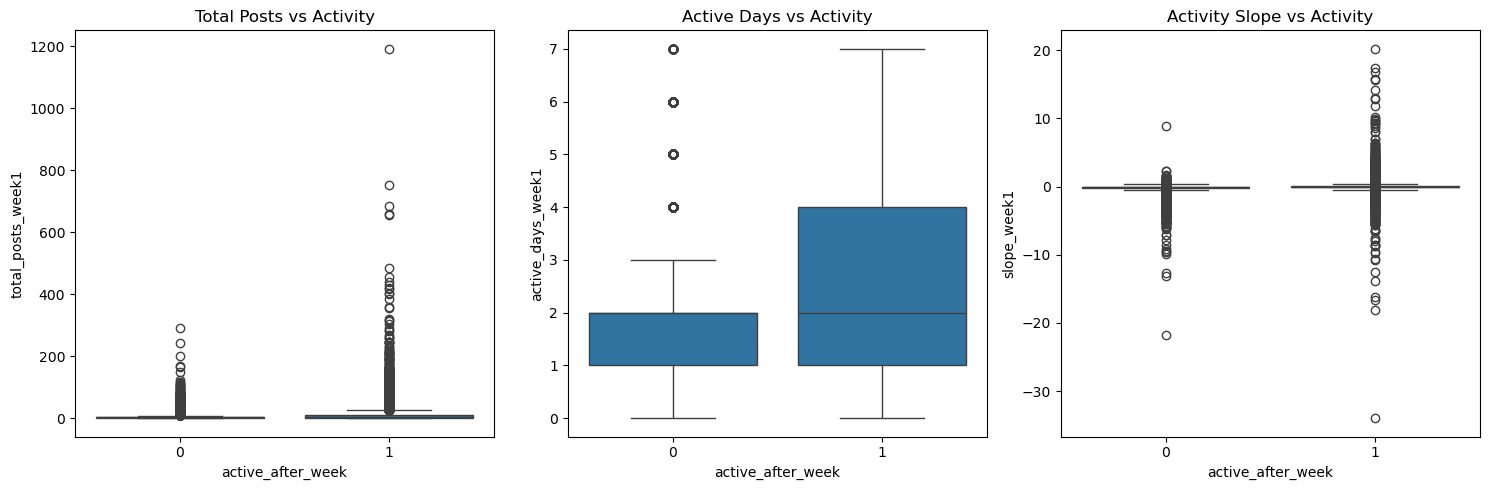

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature distributions by target class
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='active_after_week', y='total_posts_week1', data=df)
plt.title('Total Posts vs Activity')

plt.subplot(1, 3, 2)
sns.boxplot(x='active_after_week', y='active_days_week1', data=df)
plt.title('Active Days vs Activity')

plt.subplot(1, 3, 3)
sns.boxplot(x='active_after_week', y='slope_week1', data=df)
plt.title('Activity Slope vs Activity')

plt.tight_layout()
plt.show()

# Save teh file 

In [14]:
# Save features and target separately
features_output_path = "/home/ale/Documents/uni/mp/data/posting_behaviour/features/features.parquet"
target_output_path = "/home/ale/Documents/uni/mp/data/posting_behaviour/features/target.parquet"

# Save as separate files - Convert y to DataFrame first
X.to_parquet(features_output_path, index=False)
y.to_frame().to_parquet(target_output_path, index=False)  # Convert Series to DataFrame

print(f"\nFeatures saved to: {features_output_path}")
print(f"Target saved to: {target_output_path}")


Features saved to: /home/ale/Documents/uni/mp/data/posting_behaviour/features/features.parquet
Target saved to: /home/ale/Documents/uni/mp/data/posting_behaviour/features/target.parquet
